# Comparing old and new dataset class.

In [1]:
from pathlib import Path
from typing import Tuple
import json

from torch.utils.data import Dataset
import numpy as np
import torch
from torch import Tensor, set_default_dtype, float64, tensor

from repitframework.config import TrainingConfig, NaturalConvectionConfig
from repitframework.Metrics.ResidualNaturalConvection import residual_mass
from repitframework.Dataset.utils import hard_constraint_bc, add_feature

set_default_dtype(float64)

class FVMNDataset_old(Dataset):
	def __init__(
			self, 
			training_config:TrainingConfig, 
			first_training:bool, 
			data_path:Path=None, 
			start_time:float=None, 
			end_time:float=None, 
			time_step:float=None, 
			vars_list:list=None
		):
		'''
		Keep in mind
		------------
		1. To prepare for the training data, we must have numpy files from start_time to end_time mentioned here.
		Example: 
		start_time = 0, end_time=5, then we must have numpy files from 0 to 5.
		2. We don't use the fifth time step data as a network input. 
		but, we use the difference between the fifth and fourth time step as a network label.
		Example: 
		we give input from start_time(0) to end_time(5) - time_step(1) then labels will be:
		1 - 0 : 1st label
		2 - 1 : 2nd label
		3 - 2 : 3rd label
		4 - 3 : 4th label
		5 - 4 : 5th label

		input_shape from 0 to 4: [(grid_x-2) * (grid_y-2) * 5, 15]
		label_shape from 1 to 5: [(grid_x-2) * (grid_y-2) * 5, 3]

		Note
		----
		vars_list: 
			list containing the variables to be predicted. If None, it will be taken from the training_config.
			Here, we should be careful that we are not extending the dimensions of variables like
			U_x, U_y, U_z (we did while creating the network).
			Example: ["U", "T"]
		'''
		super().__init__()
		self.training_config = training_config
		self.first_training = first_training
		self.start_time = self.training_config.training_start_time if not start_time else start_time
		self.end_time = self.training_config.training_end_time if not end_time else end_time
		self.vars: list = self.training_config.get_variables() if not vars_list else vars_list
		self.time_step = self.training_config.write_interval if not time_step else time_step   


		self.time_list = self._generate_intervals()
		self.grid_x = self.training_config.grid_x
		self.grid_y = self.training_config.grid_y
		############## ------------ Data Integrity Check --------------############

		# First thing first, we must ensure that we have the data from start_time to end_time
		# in the data_path directory.
		self.data_path = self.training_config.assets_dir if not data_path else Path(data_path)
		assert self.data_path.exists(), f"Data path: {self.data_path} doesn't exist."
		assert self._is_present(), \
			f"\nData is missing in the directory: {self.data_path}:\n" + \
			f"You must have data from {start_time} to {end_time} for variables: {self.vars}. Example: {self.vars[0]}_{start_time}.npy"
		assert self.start_time != 0, "Start time can't be zero. We don't have functionality to implement initial condition in the dataset."     
		############ ----------------------------------------------############
		# Preprocess inputs and labels:
		self.inputs, self.labels = self._prepare_inputs_and_labels()

	def _is_present(self) -> bool:
		for var in self.vars:
			for time in self.time_list:
				var_path = self.data_path / f"{var}_{round(time, self.training_config.round_to)}.npy"
				if not var_path.exists():
					return False
		return True
	
	def _calculate_residual(self, time) -> float:
		'''
		Calculate the residual mass.
		'''
		data_path = self.data_path / f"U_{time}.npy"
		vel_data = self.parse_numpy(self.training_config, data_path)
		ux_matrix = vel_data[:,:,0]
		uy_matrix = vel_data[:,:,1]
		return residual_mass(ux_matrix, uy_matrix)
	
	@staticmethod
	def parse_numpy(training_config:TrainingConfig, data_path:Path) -> np.ndarray:
		'''
		This function is used to parse the numpy files.
		1. If the data is VECTOR, split the data into x, y, z components.
		2. If the data is SCALAR, keep the data as it is.
		3. Reshape the data into shapes defined in training_config: grid_x, grid_y
		   using C-order i.e row-major order because OpenFOAM stores the data in row-major order.

		Args
		----
		training_config: TrainingConfig
			The training configuration object.
		data_path: Path
			The full path to the numpy file.

		Returns
		-------
		parsed_data: np.ndarray
		- If the data is VECTOR, it will return [grid_y, grid_x, 2] shape.
		- If the data is SCALAR, it will return [grid_y, grid_x] shape.

		Example
		-------
		Let's say we have saved data from OpenFOAM to numpy as U_1.npy,\n
		and it is two-dimensional data with grid_x=200, grid_y=200.\n
		This function will return [200, 200, 2] shape.
		'''

		grid_x = training_config.grid_x
		grid_y = training_config.grid_y
		data:np.ndarray = np.load(data_path)
		assert data.shape[0] == grid_x * grid_y, "check data shape and grid size mentioned in config"
		match len(data.shape):
			case 2: # (40000, 3): when get from OpenFOAM. VECTOR data
				if training_config.data_dim == 1: # 1D
					assert data.shape[-1] >= 1, "Check the data shape. Dimensions should be >= 1."
					return data[:,0].reshape(grid_x, grid_y)
				elif training_config.data_dim == 2: #2D
					assert data.shape[-1] >= 2, "Check the data shape. Dimensions should be >= 2."
					# Check: https://github.com/JBNU-NINE/repit_container/blob/main/repit_wiki/Data-Loader-for-FVMN.md
					x_data = data[:,0].reshape(grid_x, grid_y, )
					y_data = data[:,1].reshape(grid_x, grid_y, )
					return np.stack([x_data, y_data], axis=-1)
				elif training_config.data_dim == 3: #3D

					assert data.shape[-1] == 3, "Check the data shape. Dimensions should be 3."
					x_data = data[:,0].reshape(grid_x, grid_y, )
					y_data = data[:,1].reshape(grid_x, grid_y, )
					z_data = data[:,2].reshape(grid_x, grid_y, )
					return np.stack([x_data, y_data, z_data], axis=-1)
				else: # Beyond 3D
					raise NotImplementedError("This framework doesn't support beyond 3D.")
			case 1: # SCALAR data
				return data.reshape(grid_x, grid_y, )
			case _:
				raise NotImplementedError("Till now, we have not come across this use case.")
		
	def _add_zero_padding(self, data:np.ndarray) -> np.ndarray:
		return np.pad(data, 1, mode="constant", constant_values=0)

	@staticmethod
	def add_feature(input_matrix:np.ndarray) -> np.ndarray:
		'''
		This function is used to add correlated features to the data.
				  |        |
				  | (x-1,y)|                 
		----------|--------|---------      
		 (x,y-1)  |  (x,y) | (x,y+1)   ---> [(x,y), (x-1,y), (x+1,y), (x,y-1), (x,y+1)]
		----------|--------|---------
				  |(x-1,y) | 
				  |        |
					 
		Args
		----
		input_matrix: np.ndarray
			The input data matrix. Example Shape: [200,200]

		Returns
		-------
		correlated_features: np.ndarray
			The correlated features. Example Shape: [39204, 5]

		'''
		window_shape = (3, 3)
		sliding_window = np.lib.stride_tricks.sliding_window_view(input_matrix, window_shape)
		x,y = window_shape[0] // 2, window_shape[1] // 2 
		correlated_features = [
			sliding_window[:,:,x,y],
			sliding_window[:,:,x-1,y],
			sliding_window[:,:,x+1,y],
			sliding_window[:,:,x,y-1],
			sliding_window[:,:,x,y+1]
		]
		correlated_features = [data.reshape(-1, ) for data in correlated_features]
		return np.stack(correlated_features, axis=-1)
	
	def _prepare_input(self, time) -> np.ndarray:
		'''
		Regarding the order of the variables in input data, two things matter: 
		1. The list of variables in the config file: "data_vars"
		2. The dimension of the data: 1D, 2D, 3D defined in the config file as "data_dim"

		Example
		-------
		1. If data_vars = ["U", "T"] and data_dim = 2, then the order of the variables in the input data will be: 
			U_x, U_y, T
		2. If data_vars = ["T", "U"] and data_dim = 3, then the order of the variables in the input data will be:
			T, U_x, U_y, U_z

		Functionality
		-------------
		1. Load the numpy files from the data_path directory. [U_0.npy, T_0.npy]
		2. Parse the numpy files.
		   a. If the data is VECTOR, split the data into x, y, z components. From this function: we get [200,200,2] shape.
		   b. If the data is SCALAR, keep the data as it is. From this function: we get [200,200] shape.
		3. Add zero padding to the data. From this function: we get [202,202] shape.
		4. Add correlated features to the data. From this function: we get [40000,5] shape.
		5. We exclude the boundary cells from the data. From this function: we get [39204,5] shape i.e. (200-2) * (200-2) = 39204
		5. Concatenate the data. From this function: we get [39204,15] shape. if we have 3 variables in the data_vars. 
		'''
		data_path = self.data_path
		full_data_path = [data_path / f"{var}_{time}.npy" for var in self.vars if var != "phi"]
		numpy_data = [self.parse_numpy(self.training_config, data_path) for data_path in full_data_path]
		temp = list()
		for data in numpy_data:
			if len(data.shape) > 2:
				for i in range(self.training_config.data_dim):
					temp.append(data[:,:,i])
			else:
				temp.append(data)

		if self.training_config.bc_type != "ground_truth":
			temp = self.hard_constraint_bc(temp)

		data = [self.add_feature(data) for data in temp]  
		return np.concatenate(data, axis=-1)

	def _calculate_difference(self, time) -> np.ndarray:
		'''
		If we have data from 0s to 5s and input data should be from 0s to 4s. 
		This function calculates the labels(target data) as difference between two consecutive time steps.
		Example: 
		1 - 0: 1st label
		2 - 1: 2nd label
		3 - 2: 3rd label
		4 - 3: 4th label
		5 - 4: 5th label
		'''
		data_t = self._prepare_input(time)
		data_t_next = self._prepare_input(round(time + self.time_step, self.training_config.round_to))
		return data_t_next[:,::5] - data_t[:,::5]
	
	@staticmethod
	def normalize(data, mean=None, std=None) -> Tuple[Tensor, float, float]:
		'''
		Normalize the data.
		Args
		----
		data: np.ndarray
			The data to be normalized.

		Returns
		-------
		normalized_data: Tensor
			The normalized data.
		mean: float
			The mean of the data.
		std: float
			The standard deviation of the data.
		'''
		if isinstance(data, Tensor):
			data = data.cpu().numpy()
		mean = np.mean(data, axis=0) if mean is None else mean
		std = np.std(data, axis=0) if std is None else std
		normalized_data = (data - mean)/std
		return torch.from_numpy(normalized_data).double(), mean, std
	
	@staticmethod
	def denormalize(data:Tensor, mean_, std_)->Tensor:
		if isinstance(data, Tensor): data = data.cpu().numpy()
		if data.shape[-1] == len(mean_): 
			return torch.from_numpy(data * std_ + mean_).double()
		skip_steps = len(mean_) // data.shape[-1]
		return torch.from_numpy(data * std_[::skip_steps] + mean_[::skip_steps]).double()
	
	def _prepare_inputs_and_labels(self) -> Tuple[Tensor, Tensor]:
		inputs, labels = [], []
		for time in self.time_list[:-1]: # We are excluding the last time step because it is t+1 in _calculate_difference.
			inputs.append(self._prepare_input(time))
			labels.append(self._calculate_difference(time))
		inputs = np.concatenate(inputs, axis=0)
		labels = np.concatenate(labels, axis=0)

		metrics_save_path = self.training_config.model_dump_dir / "denorm_metrics.json"
		if self.first_training:
			normalized_inputs,input_MEAN, input_STD = self.normalize(inputs)
			normalized_labels,label_MEAN, label_STD = self.normalize(labels)
			# Saving the mean and std for denormalization while predicting.
			true_residual_mass = self._calculate_residual(self.end_time)
			# While preparing for new inputs and labels, if this file already exists, it will be overwritten.
			with open(metrics_save_path, "w") as f:
				json.dump(
					{
						"input_MEAN": input_MEAN.tolist(), 
						"input_STD": input_STD.tolist(), 
						"label_MEAN": label_MEAN.tolist(), 
						"label_STD": label_STD.tolist(),
						"true_residual_mass":true_residual_mass
					}, f, indent=4
					)
			return normalized_inputs, normalized_labels
		
		with open(metrics_save_path, "r") as f: metrics = json.load(f)
		input_MEAN = metrics["input_MEAN"]
		input_STD = metrics["input_STD"]
		label_MEAN = metrics["label_MEAN"]
		label_STD = metrics["label_STD"]

		normalized_inputs, *_ = self.normalize(inputs, input_MEAN, input_STD)
		normalized_labels, *_ = self.normalize(labels, label_MEAN, label_STD)

		return normalized_inputs, normalized_labels
	
	def hard_constraint_bc(
		self, 
		data_list
	):
		'''
		We are just encoding the boundary conditions as an extra layer to the predicted values. 
		Also, while preparing the training data, we need to ensure that the boundary conditions are 
		imposed the same way.
		
		Args
		----
		ux_matrix: torch.Tensor
			shape: (grid_y, grid_x)
		uy_matrix: torch.Tensor
			shape: (grid_y, grid_x)
		t_matrix: torch.Tensor
			shape: (grid_y, grid_x)

		ux and uy are noSlip conditions, hence they should be zero.
		'''
		
		vars_list = self.training_config.extend_variables()
		ux_matrix = data_list[vars_list.index("U_x")]
		uy_matrix = data_list[vars_list.index("U_y")]
		t_matrix = data_list[vars_list.index("T")]

		ux_matrix = np.pad(ux_matrix, ((1,1),(1,1)), mode="constant", constant_values=0)
		uy_matrix = np.pad(uy_matrix, ((1,1),(1,1)), mode="constant", constant_values=0)
		t_matrix = np.pad(t_matrix, ((1,1),(1,1)), mode="constant", constant_values=0)

		'''
		Applying the boundary conditions:
		While reshaping the data, we are using order="F" to try to keep the data in the same order as OpenFOAM.
		But the numpy puts lower wall at the top and upper wall at the bottom. Hence, we need to flip.
		Naturally: 
			- Right wall is the cold wall
			- Left wall is the hot wall

		Numpy:
			- Top wall is the hot wall
			- Bottom wall is the cold wall

		But if order="C":
			- Left wall is the hot wall
			- Right wall is the cold wall
		'''

		# Because the problem domain is rotated 90 degrees; left goes to top and right goes to bottom.
		top_wall_temperature = 307.75
		bottom_wall_temperature = 288.15

		# t_matrix[:, 0] = t_matrix[:, 1]
		# t_matrix[:, -1] = t_matrix[:, -2]
		# t_matrix[0, :] = top_wall_temperature
		# t_matrix[-1, :] = bottom_wall_temperature
		
		t_matrix[:, 0] = top_wall_temperature
		t_matrix[:, -1] = bottom_wall_temperature
		t_matrix[0, :] = t_matrix[1, :]
		t_matrix[-1, :] = t_matrix[-2, :]

		data_list[vars_list.index("U_x")] = ux_matrix
		data_list[vars_list.index("U_y")] = uy_matrix
		data_list[vars_list.index("T")] = t_matrix

		return data_list

	def _generate_intervals(self,):
		time_list = []
		running_time = self.start_time
		while running_time <= self.end_time:
			time_list.append(round(running_time, self.training_config.round_to))
			running_time = round(running_time+self.time_step, self.training_config.round_to)
		return time_list
	
	def __len__(self):
		return self.inputs.shape[0]
	
	def __getitem__(self, idx):
		return self.inputs[idx], self.labels[idx]


training_config = NaturalConvectionConfig()

dataset_old_type = FVMNDataset_old(
	training_config=training_config,
	first_training=True,
	data_path=Path("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1_backup"),
	start_time=10.0,
	end_time=10.03)

inputs_old, labels_old = dataset_old_type._prepare_inputs_and_labels()


In [2]:
from repitframework.Dataset.fvmn import FVMNDataset

dataset_new_type = FVMNDataset(
			start_time=10.0,
			end_time=10.03,
			time_step=0.01,
			dataset_dir=Path("/home/shilaj/repitframework/repitframework/Assets/natural_convection_case1_backup"),
			first_training=True,
			vars_list=training_config.get_variables(),
			extended_vars_list=training_config.extend_variables(),
			do_normalize=True,
			left_wall_temperature=307.75,
			right_wall_temperature=288.15,
			do_feature_selection= True,
            output_dims="BD"
		)

inputs_new, labels_new = dataset_new_type._inputs_labels()

In [ ]:
torch.allclose(inputs_old, inputs_new)


True

In [22]:
torch.allclose(labels_old, labels_new)

True

In [6]:
inputs_new

tensor([[ 3.3323e+00,  3.4925e+00,  3.3634e+00,  ...,  5.9374e-01,
         -1.6620e-02,  2.7760e-02],
        [ 5.8356e-01,  6.3075e-01,  5.4926e-01,  ...,  6.7363e-02,
          2.2210e-01, -2.0351e-02],
        [-3.2142e-03,  1.9852e-02, -3.8716e-02,  ..., -9.8757e-02,
         -2.2405e-02, -1.3120e-02],
        ...,
        [-3.4482e-01, -3.1142e-01, -3.5383e-01,  ..., -4.3094e-04,
          1.6443e-03,  2.7943e-02],
        [-6.7747e-01, -6.5360e-01, -6.7446e-01,  ..., -4.3094e-04,
          5.5334e-03, -1.0490e-01],
        [-1.7951e+00, -1.8643e+00, -1.7517e+00,  ..., -4.3094e-04,
         -2.2238e-02,  3.4090e-02]])

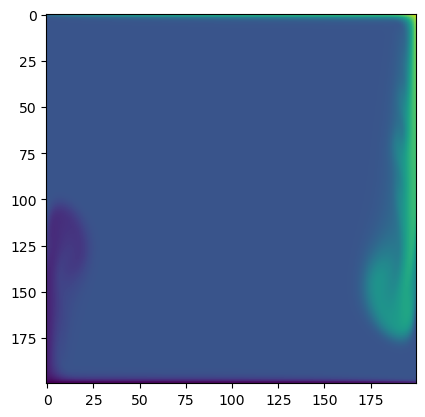

In [11]:
import matplotlib.pyplot as plt
plt.imshow(inputs_new[:40000, 0].numpy().reshape(200,200,order="F"))

## pyvista visualization

In [ ]:
#!/usr/bin/env python3
"""
Exact ParaView Visualization Match
Creates the EXACT same visualization as shown in the ParaView state file
"""

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Enable offscreen rendering
pv.start_xvfb()

def create_exact_paraview_visualization():
    """
    Create the exact same visualization as ParaView state file
    """
    print("Creating exact ParaView match visualization...")
    
    # Create mesh - matching original dimensions
    nx, ny, nz = 64, 64, 64
    mesh = pv.ImageData(dimensions=(nx, ny, nz))
    mesh.origin = (0.0, 0.0, 0.0)
    mesh.spacing = (1.0/(nx-1), 1.0/(ny-1), 1.0/(nz-1))
    
    # Generate realistic natural convection data
    x, y, z = np.meshgrid(
        np.linspace(0, 1, nx),
        np.linspace(0, 1, ny), 
        np.linspace(0, 1, nz),
        indexing='ij'
    )
    
    # Temperature field - natural convection pattern
    # Hot bottom (z=0), cold top (z=1)
    T_base = 288.15 + 19.6 * (1 - z)  # Linear temperature gradient
    
    # Add convection cells
    T_conv = 5 * np.sin(2*np.pi*x) * np.sin(2*np.pi*y) * np.exp(-2*z)
    T_conv += 3 * np.sin(4*np.pi*x) * np.cos(3*np.pi*y) * np.exp(-3*z)
    
    temperature = T_base + T_conv
    
    # Velocity field - buoyancy-driven flow
    # Rayleigh-Benard convection pattern
    u = 0.1 * np.sin(2*np.pi*x) * np.cos(2*np.pi*y) * (1-z)**2
    v = 0.1 * np.cos(2*np.pi*x) * np.sin(2*np.pi*y) * (1-z)**2
    w = 0.05 * np.sin(np.pi*x) * np.sin(np.pi*y) * np.sin(np.pi*z)
    
    # Add circulation patterns
    w += 0.08 * (temperature - 298) / 10.0  # Buoyancy effect
    
    # Flatten for mesh
    temperature_flat = temperature.flatten()
    velocity_flat = np.column_stack([u.flatten(), v.flatten(), w.flatten()])
    velocity_magnitude = np.linalg.norm(velocity_flat, axis=1)
    
    # Add data to mesh
    mesh['T'] = temperature_flat
    mesh['U'] = velocity_flat
    mesh['U_magnitude'] = velocity_magnitude
    
    print(f"✓ Mesh created: {mesh.n_points} points")
    print(f"✓ Temperature range: {temperature_flat.min():.2f} - {temperature_flat.max():.2f} K")
    print(f"✓ Velocity magnitude range: {velocity_magnitude.min():.4f} - {velocity_magnitude.max():.4f}")
    
    # Create the visualization
    plotter = pv.Plotter(off_screen=True, window_size=[1537, 896])  # Exact ParaView window size
    plotter.set_background('white')
    
    # 1. Add temperature slices (matching ParaView setup)
    # Slice 1: Z=0.5 plane (middle)
    slice_z = mesh.slice(normal='z', origin=[0.5, 0.5, 0.5])
    
    # Slice 2: X=0.5 plane (middle) 
    slice_x = mesh.slice(normal='x', origin=[0.5, 0.5, 0.5])
    
    # Create exact ParaView colormap (blue to red)
    # Based on ParaView state: RGBPoints = [288.15, 0.231, 0.298, 0.753, 297.95, 0.865, 0.865, 0.865, 307.75, 0.705, 0.0157, 0.149]
    from matplotlib.colors import LinearSegmentedColormap
    colors_rgb = [
        [0.231, 0.298, 0.753],  # Blue for cold (288.15 K)
        [0.865, 0.865, 0.865],  # Light gray for middle (297.95 K) 
        [0.705, 0.0157, 0.149]  # Red for hot (307.75 K)
    ]
    paraview_cmap = LinearSegmentedColormap.from_list('paraview', colors_rgb, N=256)
    
    # Add temperature slices
    plotter.add_mesh(slice_z, scalars='T', 
                    cmap=paraview_cmap,
                    clim=[288.15, 307.75],
                    scalar_bar_args={
                        'title': 'T',
                        'title_font_size': 16,
                        'label_font_size': 14,
                        'color': 'black',
                        'position_x': 0.74,  # Match ParaView position
                        'position_y': 0.28,
                        'width': 0.08,
                        'height': 0.33
                    })
    
    plotter.add_mesh(slice_x, scalars='T', 
                    cmap=paraview_cmap,
                    clim=[288.15, 307.75],
                    show_scalar_bar=False)  # Only show one scalar bar
    
    # 2. Add streamlines (matching ParaView StreamTracer settings)
    # Create streamlines from center point cloud
    streamlines = mesh.streamlines(
        vectors='U',
        source_center=[0.5, 0.5, 0.5],
        source_radius=0.3,
        n_points=1000,
        max_time=100,
        integration_direction='both'
    )
    
    plotter.add_mesh(streamlines, 
                    scalars='T',
                    cmap=paraview_cmap,
                    clim=[288.15, 307.75],
                    line_width=2,
                    show_scalar_bar=False)
    
    # 3. Add velocity glyphs (arrows)
    # Subsample for glyphs - match ParaView glyph settings
    glyph_mesh = mesh.extract_subset([0, nx-1, 0, ny-1, 0, nz-1], [6, 6, 6])  # Sparse sampling
    
    glyphs = glyph_mesh.glyph(
        orient='U', 
        scale='U_magnitude',
        factor=0.055,  # Match ParaView ScaleFactor: 0.0549973080531936
        geom=pv.Arrow()
    )
    
    # Color glyphs by temperature
    plotter.add_mesh(glyphs, 
                    scalars='T',
                    cmap=paraview_cmap,
                    clim=[288.15, 307.75],
                    show_scalar_bar=False)
    
    # 4. Set exact camera position (from ParaView state)
    plotter.camera_position = [
        [1.9741244611670297, 1.4882461480898839, 3.3366316374324088],  # camera position
        [0.4999999999999992, 0.5000000000000001, 0.5],                 # focal point
        [-0.14108528887086216, 0.9553758935313872, -0.25952233684854376] # view up
    ]
    
    # 5. Add 3D axes (matching ParaView GridAxes3DActor)
    plotter.show_axes()
    
    # Save the exact visualization
    output_path = '/home/shilaj/shilaj_data/repitframework/random/paraview_results/exact_paraview_match.png'
    plotter.screenshot(output_path, transparent_background=False)
    plotter.close()
    
    print(f"✓ Exact ParaView visualization saved: {output_path}")
    return output_path

if __name__ == '__main__':
    print("=" * 60)
    print("Creating EXACT ParaView Visualization Match")
    print("=" * 60)
    
    output_file = create_exact_paraview_visualization()
    
    print("=" * 60)
    print("🎉 SUCCESS: Exact ParaView match created!")
    print(f"📁 Output: {output_file}")
    print("=" * 60)

In [2]:
import imageio
import os 


images = []
for file_name in sorted(os.listdir("paraview_results/animation_plots_true")):
	if file_name.endswith(".png"):
		file_path = os.path.join("paraview_results/animation_plots_true", file_name)
		images.append(imageio.imread(file_path))

imageio.mimwrite('paraview_results/animation_plots_true/animation_true_coarse_grid.mp4', images, fps=100)

/tmp/ipykernel_390030/231051861.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file_path))
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3074, 1792) to (3088, 1792) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
